In [1]:
import os
import sys
from loguru import logger
import torch
import numpy as np
import matplotlib.pyplot as plt
import torchvision.transforms as transforms

if os.path.abspath("..") not in sys.path:
    sys.path.append(os.path.abspath(".."))

from hippy2d.utils import get_testing_img

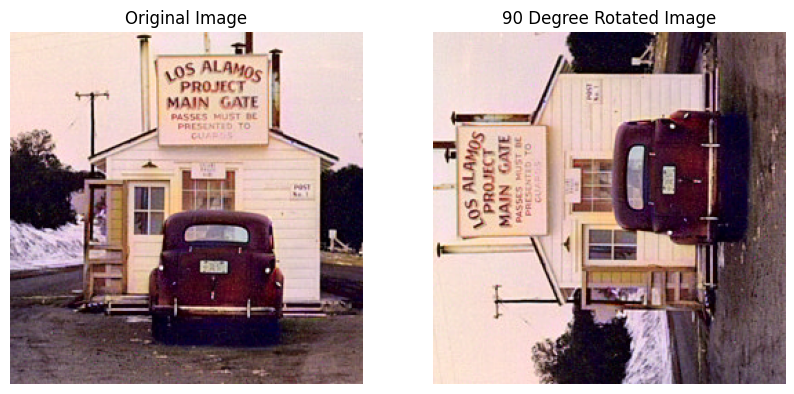

In [2]:
# Simulate RGB channels
test_img_rgb = get_testing_img(rgb=True)
test_img_rgb = transforms.ToTensor()(test_img_rgb).to(dtype=torch.float64)[None, : ].to(dtype=torch.float32)
rotated_img_rgb = torch.rot90(test_img_rgb, 1, [-2, -1]).to(dtype=torch.float32)

# Plot the images
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(test_img_rgb[0].permute(1, 2, 0).numpy(), cmap='gray')
plt.title("Original Image")
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(rotated_img_rgb[0].permute(1, 2, 0).numpy(), cmap='gray')
plt.title("90 Degree Rotated Image",)
plt.axis('off')
plt.show()

# Standardize the images 
mean = test_img_rgb.mean(dim=[0, 2, 3], keepdim=True)
std = test_img_rgb.std(dim=[0, 2, 3], keepdim=True)
test_img_rgb = (test_img_rgb - mean) / std
rotated_img_rgb = (rotated_img_rgb - mean) / std

In [186]:
import escnn
r2_act = escnn.gspaces.rot2dOnR2(N=-1, maximum_frequency=3)
in_type = escnn.nn.FieldType(r2_act, [r2_act.trivial_repr] * 3)  # RGB input
out_channels = 4
kernel_size = 7
irreps = None

if irreps is None: 
    irreps = []
    for n, irr in enumerate(r2_act.fibergroup.irreps()):
        if not irr.is_trivial():
            irreps += [irr] * int(irr.size // irr.sum_of_squares_constituents)
    irreps = list(irreps)


trivials = escnn.nn.FieldType(r2_act, [r2_act.trivial_repr] * out_channels)
norm_factor = escnn.group.directsum([r2_act.irrep(1)]  * out_channels, name="norm_factor")
norm_factor = escnn.nn.FieldType(r2_act, [norm_factor])
non_trivials = escnn.nn.FieldType(r2_act, sorted(irreps * out_channels, key=lambda r: r.id))
conv_type = trivials + norm_factor + non_trivials
# Prepare convolutional layer
conv = escnn.nn.R2Conv(in_type,
                       conv_type,
                       kernel_size=kernel_size,
                       padding=2,
                       sigma=0.6,
                       initialize=True)
conv.weights = torch.nn.Parameter(torch.ones_like(conv.weights) * 0.1)

In [187]:
x = test_img_rgb
x = escnn.nn.GeometricTensor(x, in_type)
x = conv(x)
x.shape
out_type = conv.out_type

In [ ]:
# number of fields of each type
from collections import defaultdict
from hippy2d.utils import SafeAtan2
from einops import repeat

def _complex_mul(x, y, complex_dim=3):
    xr, xi = torch.unbind(x, dim=complex_dim)  # real, imag
    yr, yi = torch.unbind(y, dim=complex_dim)
    real = xr * yr - xi * yi
    imag = xr * yi + xi * yr
    return torch.stack((real, imag), dim=complex_dim)

def _rotate_moments(moments: torch.Tensor,
                    exponents: torch.Tensor,
                    eps=1e-8,
                    magnitude_func='normed',
                    complex_dim=3
                    ) -> torch.Tensor:
    if magnitude_func == 'copy':
        magnitude = torch.norm(moments, dim=complex_dim)
        moment_real, moment_imag = torch.unbind(moments, dim=complex_dim)
        angle = SafeAtan2.apply(moment_imag, moment_real, eps)
        new_magnitude = magnitude * torch.ones_like(exponents)
        new_angle = angle * exponents 

        result_real = new_magnitude * torch.cos(new_angle)
        result_imag = new_magnitude * torch.sin(new_angle)
        return torch.stack([result_real, result_imag], dim=complex_dim)
    elif magnitude_func == 'normed':
        norm_moment = moments / torch.clamp(torch.norm(moments, dim=complex_dim), min=eps)
        new_magnitude = torch.norm(moments, dim=complex_dim) # Keep zeros
        moment_real, moment_imag = torch.unbind(norm_moment, dim=complex_dim)
        angle = SafeAtan2.apply(moment_imag, moment_real, eps)
        new_angle = angle * exponents
        result_real = new_magnitude * torch.cos(new_angle)
        result_imag = new_magnitude * torch.sin(new_angle)
        return torch.stack([result_real, result_imag], dim=complex_dim)
    else: 
        raise NotImplementedError(f"magnitude_func '{magnitude_func}' not implemented")

class InvariantLayer(escnn.nn.EquivariantModule): 
    def __init__(self, 
                 r2_act: escnn.gspaces.rot2dOnR2,
                 in_type: escnn.nn.FieldType,
                 in_channels: int):
        super(InvariantLayer, self).__init__()
        # Check norm_factor in the input type
        assert "norm_factor" in [r.name for r in in_type.representations], "Input type must contain norm_factor representation"

        self.in_type = in_type
        # To be init function 
        nfields = defaultdict(int)

        # indices of the channels corresponding to fields belonging to each group
        _indices = defaultdict(lambda: [])

        # whether each group of fields is contiguous or not
        _contiguous = {}
        # Assert that the input representation contains norm_factor of size channels 


        position = 0
        types = []
        last_field = None
        output_size = 0 
        for _, r in enumerate(out_type.representations):
            if r.name == "irrep_0":
                name = "trivial"
                output_size += r.size
            elif r.name == "norm_factor":
                name = "norm_factor"
            else:
                name = "non_trivial"
                output_size += r.size

            if name != last_field:
                if not name in _contiguous:
                    _contiguous[name] = True
                else:
                    raise NotImplementedError("Non-contiguous fields are not supported yet.")

            last_field = name
            _indices[name] += list(range(position, position + r.size))
            if r.name != "norm_factor" and r.name != "irrep_0":
                types += r.id
            nfields[r.name] += 1
            position += r.size

        for name, _ in _contiguous.items():
            _indices[name] = [min(_indices[name]), max(_indices[name])+1]
        exponents = []
        for name, count in nfields.items():
            if name == "norm_factor" or name == "irrep_0":
                continue
            else: 
                assert count == in_channels, f"All fields of type {name} must have the same number of channels. Found {count} instead of {in_channels}."
                order = torch.tensor(int(name.split('_')[1]))
                assert order > 0, "Only non-trivial representations are supported."
                # Exponents Channels x Complex x H x W
                order = repeat(order, '-> c 1 1 1', c=in_channels)
                exponents.append(order)
        exponents = torch.stack(exponents, dim=0) # Orders x Channels x Complex x H x W


        self.register_buffer("trivial_indices", torch.tensor(_indices["trivial"]))
        self.register_buffer("non_trivial_indices", torch.tensor(_indices["non_trivial"]))
        self.register_buffer("norm_factor_indices", torch.tensor(_indices["norm_factor"]))
        self.register_buffer("conjugate_one", torch.tensor([1.0, -1.0]).view(1, 1, 2, 1, 1))
        self.register_buffer("in_channels", torch.tensor(in_channels))
        self.register_buffer("exponents", exponents)
        self.types = types
     
        self.out_type = escnn.nn.FieldType(r2_act, [r2_act.trivial_repr] * output_size)

    def forward(self, x: escnn.nn.GeometricTensor) -> escnn.nn.GeometricTensor:
        x  = x.tensor
        b, _, h, w = x.shape
        # Trivials are kept as is
        trivials = x[:, self.trivial_indices[0]:self.trivial_indices[1], :, :]

        # Norm Factor:  Batch x Orders x Channels x Complex x H x W
        norm_factor  = x[:, self.norm_factor_indices[0]:self.norm_factor_indices[1], :, :]
        norm_factor = norm_factor.view(b, 1, self.in_channels, 2, h, w)
        norm_factor = norm_factor * self.conjugate_one
        norm_factor = self._rotate_norm_factor(norm_factor)
        
        # Non-Trivials: Batch x Orders x Channels x Complex x H x W
        non_trivials = x[:, self.non_trivial_indices[0]:self.non_trivial_indices[1], :, :]
        non_trivials = non_trivials.view(b, -1, self.in_channels, 2, h, w)

        invariants = self._complex_mul(non_trivials, norm_factor)
        invariants = invariants.view(b, -1, h, w)

        all_invariants = torch.cat([trivials, invariants], dim=1)
        return escnn.nn.GeometricTensor(all_invariants, self.out_type)


    def _rotate_norm_factor(self, 
                              norm_factor: torch.Tensor) -> torch.Tensor:

        magnitude = torch.norm(norm_factor, dim=3, keepdim=True)
        moment_real = norm_factor[:, :, :, 0:1, :, :]
        moment_imag = norm_factor[:, :, :, 1:2, :, :]
        angle = SafeAtan2.apply(moment_imag, moment_real)
        new_angle = angle * self.exponents
        new_angle.shape, magnitude.shape
        result_real = magnitude * torch.cos(new_angle)
        result_imag = magnitude * torch.sin(new_angle)
        # TODO: Normalize this by sqrt or smth else? 
        # Prepare a copy version
        return torch.cat([result_real, result_imag], dim=3)
    
    def _complex_mul(self, x: torch.Tensor, y: torch.Tensor) -> torch.Tensor:
        xr = x[..., 0:1, :, :]
        xi = x[..., 1:2, :, :]
        yr = y[..., 0:1, :, :]
        yi = y[..., 1:2, :, :]
        real = xr * yr - xi * yi
        imag = xr * yi + xi * yr
        return torch.cat((real, imag), dim=3)
        

    def check_equivariance(self, atol: float = 1e-6) -> None:
        pass

    def evaluate_output_shape(self, input_shape):
        return super().evaluate_output_shape(input_shape)

In [263]:
inv_layer = InvariantLayer(r2_act=r2_act, in_type=conv_type, in_channels=out_channels)
def _simple_net(img):
    x = img
    x = escnn.nn.GeometricTensor(x, in_type)
    x = conv(x)
    x = inv_layer(x)
    return x

invariants = _simple_net(test_img_rgb)
rotated_invariants = _simple_net(rotated_img_rgb)

# assert close
torch.testing.assert_close(invariants.tensor, torch.rot90(rotated_invariants.tensor, k=-1, dims=[-2, -1]), atol=1e-4,rtol=1e-4)

In [259]:
invariants.tensor.shape, rotated_invariants.tensor.shape

(torch.Size([1, 28, 254, 254]), torch.Size([1, 28, 254, 254]))

In [ ]:



moment_real, moment_imag = torch.unbind(moments, dim=complex_dim)
angle = SafeAtan2.apply(moment_imag, moment_real, eps)
new_magnitude = magnitude * torch.ones_like(exponents)
new_angle = angle * exponents 

result_real = new_magnitude * torch.cos(new_angle)
result_imag = new_magnitude * torch.sin(new_angle)

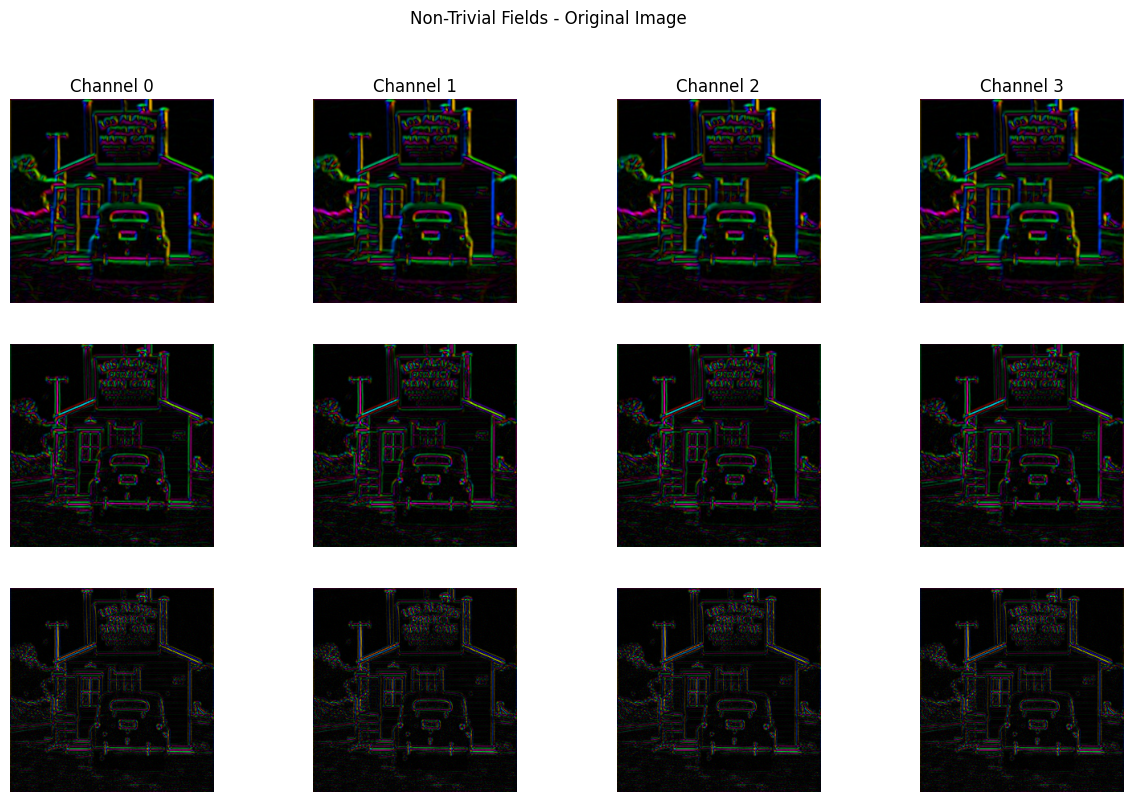

In [217]:
from hippy2d.utils import complex_to_rgb
# Plot all the channels and all the fields
_non_trivials = torch.complex(non_trivials[..., 0,:, :], non_trivials[..., 1,:, :])
num_fields = _non_trivials.shape[1]
channels = _non_trivials.shape[2]
fig, axes = plt.subplots(num_fields, channels, figsize=(15, 3 * num_fields))
for i in range(num_fields):
    for j in range(channels):
        rgb_image = complex_to_rgb(_non_trivials[0, i, j].detach().cpu())
        axes[i, j].imshow(rgb_image)
        axes[i, j].axis('off')
        if i == 0:
            axes[i, j].set_title(f'Channel {j}')
        if j == 0:
            axes[i, j].set_ylabel(f'Field {i}')
plt.suptitle("Non-Trivial Fields - Original Image")
plt.show()


In [ ]:
kkkkknon_trivials = escnn.nn.FieldType(r2_act, irreps * out_channels)
sorted(non_trivials, key=lambda r: r.name)